<a href="https://colab.research.google.com/github/LourdesBranchi/tp_final_especializacion/blob/main/02_entrenamiento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clonar repositorio

In [ ]:
!git clone https://github.com/LourdesBranchi/tp_final_especializacion.git
%cd tp_final_especializacion

!pip install segmentation-models-pytorch SimpleITK -q

Cloning into 'tp_final_especializacion'...
remote: Enumerating objects: 16, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 16 (delta 2), reused 13 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (16/16), 8.41 KiB | 8.41 MiB/s, done.
Resolving deltas: 100% (2/2), done.
/content/tp_final_especializacion
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 11.8 MB/s eta 0:00:00


In [ ]:
import os
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import pandas as pd
import time
from google.colab import userdata

from src.data_utils import cargar_metadata, particionar_pacientes, resumen_particiones, CamusDataset
from src.losses import ComboLoss
from src.models import crear_modelo
from src.metrics import dice_por_clase

In [ ]:
!pip install albumentations -q

In [ ]:
import albumentations as A
import numpy as np
import torch
from torch.utils.data import Dataset

class DatasetConAugmentation(Dataset):
    """Envuelve un CamusDataset ya creado y le agrega augmentation encima,
    sin modificar data_utils.py. Todo el augmentation vive acá, en el notebook.

    Nota: como CamusDataset ya devuelve el tensor normalizado a [0,1], el
    ruido gaussiano usa una escala mucho más chica que si operara sobre
    0-255 (que era la idea original si lo hubiéramos puesto en preprocessing.py).
    """
    def __init__(self, dataset_base):
        self.dataset_base = dataset_base
        self.augmentador = A.Compose([
            # Affine combina rotación+zoom+traslación y mantiene el tamaño
            # de salida fijo (rellena con 0 los bordes que quedan vacíos) --
            # más simple que Rotate+RandomScale por separado, que cambiaban
            # el tamaño de la imagen y obligaban a recortar después.
            A.Affine(scale=(0.9, 1.1), rotate=(-10, 10),
                     border_mode=0, cval=0, p=0.5),
            A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
            A.GaussNoise(var_limit=(0.0005, 0.002), p=0.3),  # escala ajustada para datos ya en [0,1]
        ])

    def __len__(self):
        return len(self.dataset_base)

    def __getitem__(self, idx):
        img_tensor, mask_tensor = self.dataset_base[idx]

        img_np = img_tensor.squeeze(0).numpy()          # [H, W], float32 en [0,1]
        mask_np = mask_tensor.numpy().astype(np.uint8)  # uint8 -- mismo motivo que el bug de PIL de antes

        resultado = self.augmentador(image=img_np, mask=mask_np)
        img_aug, mask_aug = resultado['image'], resultado['mask']

        img_aug_tensor = torch.from_numpy(img_aug).unsqueeze(0).float()
        mask_aug_tensor = torch.from_numpy(mask_aug).long()
        return img_aug_tensor, mask_aug_tensor

# Descargar CAMUS

In [ ]:
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

!kaggle datasets download -d shoybhasan/camus-human-heart-data
!unzip -q camus-human-heart-data.zip -d dataset_camus

import zipfile
with zipfile.ZipFile('dataset_camus/download', 'r') as zip_ref:
    zip_ref.extractall('datos_corazon')

Dataset URL: https://www.kaggle.com/datasets/shoybhasan/camus-human-heart-data
License(s): other
100% 3.50G/3.50G [00:46<00:00, 81.3MB/s]



# Metadata y partición de los datos

In [ ]:
CARPETA_BASE = 'datos_corazon/database_nifti'

df_metadata = cargar_metadata(CARPETA_BASE)
particiones = particionar_pacientes(df_metadata, n_val_por_sexo=20, n_test_por_sexo=20, seed=42)
resumen_particiones(particiones, df_metadata)

val: 40 pacientes -> {'M': 20, 'F': 20}
test: 40 pacientes -> {'F': 20, 'M': 20}
train_imbalanced: 420 pacientes -> {'M': 290, 'F': 130}
train_balanced: 260 pacientes -> {'F': 130, 'M': 130}


# Configuracion del modelo
Sección que se cambia para entrenar distintos modelos

In [ ]:
#   Modelo 1: ('unet_resnet34', 'train_imbalanced')  y  ('resdunet', 'train_imbalanced')
#   Modelo 2: (arquitectura ganadora, 'train_balanced')
ARQUITECTURA = 'unet_resnet34'
PARTICION_TRAIN = 'train_imbalanced'

NOMBRE_CORRIDA = f'{ARQUITECTURA}_{PARTICION_TRAIN}'
print(f"Corrida: {NOMBRE_CORRIDA}")

Corrida: unet_resnet34_train_imbalanced


# Dataset y dataloaders

In [ ]:
BATCH_SIZE = 16

train_ds_base = CamusDataset(particiones[PARTICION_TRAIN], CARPETA_BASE, size=256, augmentar=False)
train_ds = DatasetConAugmentation(train_ds_base)   # <- este es el que usa el DataLoader

val_ds = CamusDataset(particiones['val'], CARPETA_BASE, size=256, augmentar=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {len(train_ds)} imágenes | Val: {len(val_ds)} imágenes")

Train: 1680 imágenes | Val: 160 imágenes


/tmp/ipykernel_3155/464039237.py:21: UserWarning: Argument(s) 'cval' are not valid for transform Affine
  A.Affine(scale=(0.9, 1.1), rotate=(-10, 10),
/tmp/ipykernel_3155/464039237.py:24: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(0.0005, 0.002), p=0.3),  # escala ajustada para datos ya en [0,1]


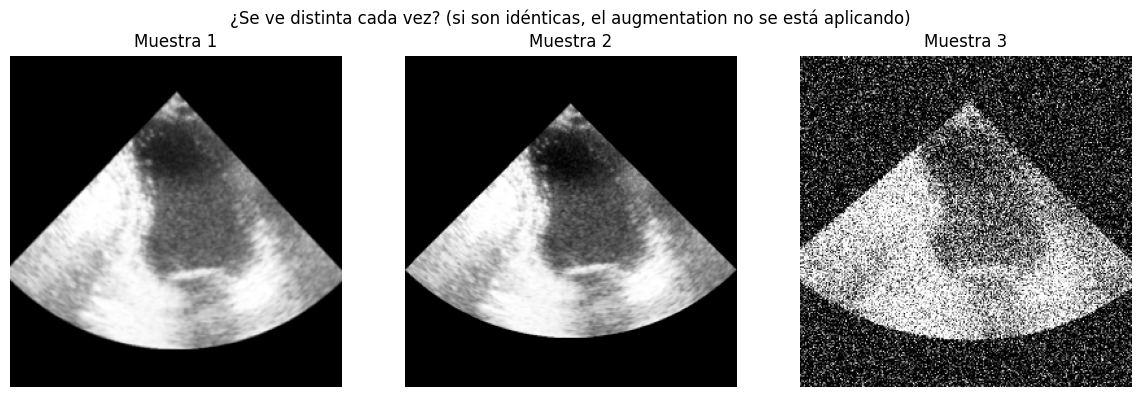

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, ax in enumerate(axes):
    img, mask = train_ds[0]  # mismo índice las 3 veces
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'Muestra {i+1}')
    ax.axis('off')
plt.suptitle('¿Se ve distinta cada vez? (si son idénticas, el augmentation no se está aplicando)')
plt.tight_layout()
plt.show()

In [ ]:
for nombre, ids in particiones.items():
    n_pacientes = len(ids)
    n_imagenes = sum(1 for pid in ids for vista in ['2CH','4CH'] for fase in ['ED','ES']
                      if os.path.exists(os.path.join(CARPETA_BASE, pid, f'{pid}_{vista}_{fase}.nii.gz')))
    print(f"{nombre}: {n_pacientes} pacientes ({n_pacientes/500*100:.1f}%) — {n_imagenes} imágenes")

val: 40 pacientes (8.0%) — 160 imágenes
test: 40 pacientes (8.0%) — 160 imágenes
train_imbalanced: 420 pacientes (84.0%) — 1680 imágenes
train_balanced: 260 pacientes (52.0%) — 1040 imágenes


# Modelo, loss y optimizador

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

modelo = crear_modelo(ARQUITECTURA, num_clases=4).to(device)
loss_fn = ComboLoss(alpha=0.5, beta=0.7)   # ver src/losses.py para la justificación de estos valores
optimizador = torch.optim.Adam(modelo.parameters(), lr=1e-4, weight_decay=1e-5)

print(f"Modelo: {ARQUITECTURA} en [{device.upper()}]")

Modelo: unet_resnet34 en [CUDA]


# Entrenamiento

In [ ]:
import json
from datetime import datetime

def entrenar(modelo, train_loader, val_loader, loss_fn, optimizador, epochs, device,
             nombre_corrida, drive_dir, config_corrida, paciencia = 7):
    """
    config_corrida: dict con TODO lo que define esta corrida (arquitectura,
        partición, alpha, beta, lr, batch_size, seed...) -- se guarda junto
        al historial para nunca perder de vista qué generó cada resultado.
    """
    os.makedirs(drive_dir, exist_ok=True)
    historial = {'train_loss': [], 'val_loss': [], 'val_dice': []}
    mejor_dice = 0.0
    epochs_sin_mejora = 0

    ruta_mejor = os.path.join(drive_dir, f'{nombre_corrida}_mejor.pt')
    ruta_ultimo = os.path.join(drive_dir, f'{nombre_corrida}_ultimo.pt')
    ruta_historial = os.path.join(drive_dir, f'{nombre_corrida}_historial.json')

    for epoch in range(epochs):
        inicio = time.time()

        modelo.train()
        loss_train_total = 0.0
        for imagenes, mascaras in train_loader:
            imagenes, mascaras = imagenes.to(device), mascaras.to(device)
            optimizador.zero_grad()
            salida = modelo(imagenes)
            loss = loss_fn(salida, mascaras)
            loss.backward()
            optimizador.step()
            loss_train_total += loss.item()

        modelo.eval()
        loss_val_total = 0.0
        dices_val = []
        with torch.no_grad():
            for imagenes, mascaras in val_loader:
                imagenes, mascaras = imagenes.to(device), mascaras.to(device)
                salida = modelo(imagenes)
                loss_val_total += loss_fn(salida, mascaras).item()
                pred = salida.argmax(dim=1)
                for i in range(pred.shape[0]):
                    dices = dice_por_clase(pred[i], mascaras[i], num_clases=4)
                    dices_val.append(dices[1:].mean())

        train_loss = loss_train_total / len(train_loader)
        val_loss = loss_val_total / len(val_loader)
        val_dice = sum(dices_val) / len(dices_val)

        historial['train_loss'].append(train_loss)
        historial['val_loss'].append(val_loss)
        historial['val_dice'].append(val_dice)

        print(f"Época {epoch+1}/{epochs} ({time.time()-inicio:.0f}s) — "
              f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_dice={val_dice:.4f}")

        # Se guarda EN CADA ÉPOCA -- es liviano (unos KB) y evita perder todo
        # si Colab se desconecta antes de terminar.
        with open(ruta_historial, 'w') as f:
            json.dump({'config': config_corrida, 'historial': historial}, f, indent=2)

        # Checkpoint "último": modelo + optimizador + época -- permite retomar
        # el entrenamiento si se corta a mitad de camino, sin arrancar de cero.
        torch.save({
            'epoch': epoch,
            'modelo_state': modelo.state_dict(),
            'optimizador_state': optimizador.state_dict(),
        }, ruta_ultimo)

        # Checkpoint "mejor": el que se usa después para evaluar/inferir.
        if val_dice > mejor_dice:
            mejor_dice = val_dice
            epocas_sin_mejora = 0
            torch.save(modelo.state_dict(), ruta_mejor)
            print(f"  ↳ nuevo mejor checkpoint (val_dice={val_dice:.4f})")
        else:
            epocas_sin_mejora += 1
            if epocas_sin_mejora >= paciencia:
                print(f"Sin mejora en {paciencia} épocas — corte anticipado en época {epoch+1}")
                break

    return historial


def registrar_resultado_final(drive_dir, nombre_corrida, config, metricas_finales):
    """Agrega una fila al CSV maestro de resultados -- una fila por corrida
    completa. Este CSV termina siendo directamente la tabla del Capítulo 4."""
    ruta_csv = os.path.join(drive_dir, 'resultados_experimentos.csv')
    fila = {'nombre_corrida': nombre_corrida,
             'timestamp': datetime.now().isoformat(timespec='seconds'),
             **config, **metricas_finales}
    df_fila = pd.DataFrame([fila])
    if os.path.exists(ruta_csv):
        df_fila.to_csv(ruta_csv, mode='a', header=False, index=False)
    else:
        df_fila.to_csv(ruta_csv, index=False)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
os.makedirs('/content/drive/MyDrive/tesis_camus', exist_ok=True)

EPOCHS = 30

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DRIVE_DIR = '/content/drive/MyDrive/tesis_camus'

config_corrida = {
    'arquitectura': ARQUITECTURA,
    'particion_train': PARTICION_TRAIN,
    'alpha': 0.5, 'beta': 0.7,
    'lr': 1e-4, 'batch_size': BATCH_SIZE, 'epochs': EPOCHS,
    'seed': 42,
}

historial = entrenar(modelo, train_loader, val_loader, loss_fn, optimizador,
                      epochs=EPOCHS, device=device, nombre_corrida=NOMBRE_CORRIDA,
                      drive_dir=DRIVE_DIR, config_corrida=config_corrida)

registrar_resultado_final(DRIVE_DIR, NOMBRE_CORRIDA, config_corrida,
                            {'mejor_val_dice': max(historial['val_dice'])})

Época 1/30 (31s) — train_loss=0.4723 val_loss=0.3958 val_dice=0.7527
  ↳ nuevo mejor checkpoint (val_dice=0.7527)
Época 2/30 (38s) — train_loss=0.3580 val_loss=0.2888 val_dice=0.8362
  ↳ nuevo mejor checkpoint (val_dice=0.8362)
Época 3/30 (37s) — train_loss=0.2163 val_loss=0.1522 val_dice=0.8815
  ↳ nuevo mejor checkpoint (val_dice=0.8815)
Época 4/30 (36s) — train_loss=0.1218 val_loss=0.0979 val_dice=0.8867
  ↳ nuevo mejor checkpoint (val_dice=0.8867)
Época 5/30 (41s) — train_loss=0.0875 val_loss=0.0792 val_dice=0.8919
  ↳ nuevo mejor checkpoint (val_dice=0.8919)
Época 6/30 (35s) — train_loss=0.0716 val_loss=0.0715 val_dice=0.8916
Época 7/30 (40s) — train_loss=0.0644 val_loss=0.0641 val_dice=0.8959
  ↳ nuevo mejor checkpoint (val_dice=0.8959)
Época 8/30 (41s) — train_loss=0.0582 val_loss=0.0624 val_dice=0.8916
Época 9/30 (36s) — train_loss=0.0548 val_loss=0.0590 val_dice=0.8976
  ↳ nuevo mejor checkpoint (val_dice=0.8976)
Época 10/30 (39s) — train_loss=0.0512 val_loss=0.0569 val_dice=0

In [ ]:
DRIVE_DIR

# Curva de entrenamiento/

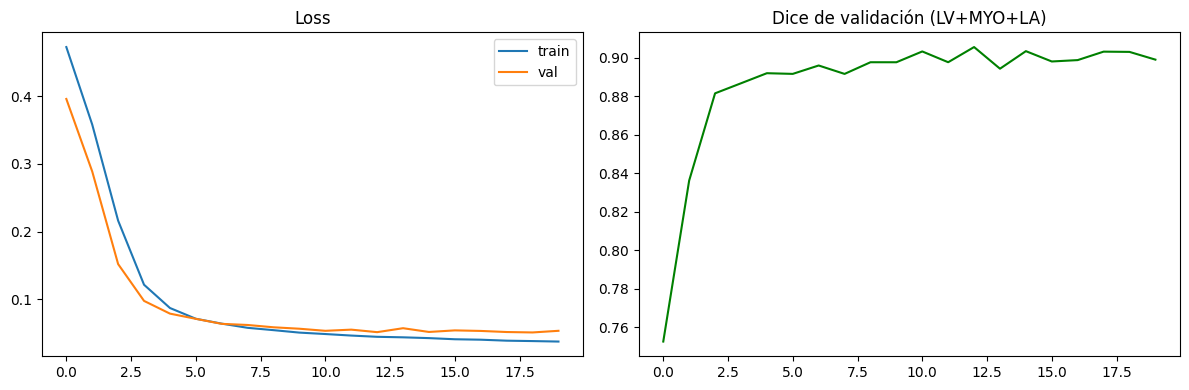

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(historial['train_loss'], label='train')
axes[0].plot(historial['val_loss'], label='val')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(historial['val_dice'], color='green')
axes[1].set_title('Dice de validación (LV+MYO+LA)')
plt.tight_layout(); plt.show()